In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot import make_theme

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

C:\Users\yshen\AppData\Local\Temp\ipykernel_21552\4225987741.py:105: RuntimeWarning: Mean of empty slice
  y = np.nanmean(Edep[0]['I_norm'], axis=0)


Text(0, 0.5, 'Intensity (arb. units)')

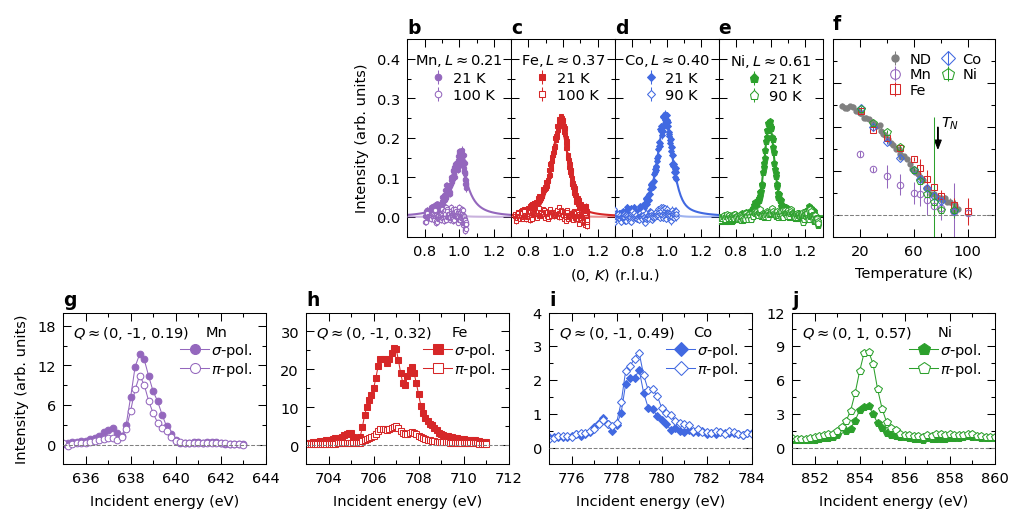

In [3]:
fig = plt.figure(figsize=(6.75,6.75/2), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=4, left=0.40, right=0.81, top=0.94, bottom=0.55, wspace=0, hspace=0)
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.82, right=0.98, top=0.94, bottom=0.55, wspace=0, hspace=0)
gs3 = fig.add_gridspec(nrows=1, ncols=4, left=0.06, right=0.98, top=0.40, bottom=0.10, wspace=0.2, hspace=0)
axs1 = [fig.add_subplot(gs) for gs in gs1]
axs2 = [fig.add_subplot(gs) for gs in gs2]
axs3 = [fig.add_subplot(gs) for gs in gs3]

# Tdep K scans
scan_lists = [[342,345,348,351,354,357,361,364,367,370,373,377],
              [269,273,277,281,285,289,294,298,302,306,310,315],
              [187,191,195,199,203,207,212,216,220,224,228],
              [78,84,89,94,99,104,109,113,117,121,126]]
edges = ['Mn', 'Fe', 'Co', 'Ni']
colors = ['C4','C3','royalblue','C2']
fmts = ['o', 's', 'D', 'p']
mkss = [2.1, 2, 2, 3]
counts = ['b', 'c', 'd', 'e']
Lrlus = [0.21, 0.37, 0.40, 0.61]
plot_params = dict(mew=0.5, elinewidth=0.5, ls='none')
for scan_list, edge, color, fmt, mks, count, Lrlu, ax in zip(scan_lists, edges, colors, fmts, mkss, counts, Lrlus, axs1):
    bg1 = dict(np.load('../reixs/data/rexs_{}.npz'.format(scan_list[-1])))
    # 21 K
    scan_no = scan_list[0]
    scan = dict(np.load('../reixs/data/rexs_{}.npz'.format(scan_no)))
    fits = dict(np.load('../reixs/fits/rexs_{}.npz'.format(scan_no)))
    fit_result = dict(np.load('../reixs/fits/results_{}.npz'.format(scan_no)))
    x = scan['x']
    bg2 = x * fit_result['bg_slope'][0] + fit_result['bg_intercept'][0]
    y = (scan['y'] - bg1['y']) / bg1['y'] - bg2
    yerr = np.sqrt(scan['yerr']**2 + bg1['yerr']**2) / bg1['y']
    ax.errorbar(-x, y, yerr, fmt=fmt, ms=mks, color=color, zorder=0, **plot_params, label='{:.0f} K'.format(scan['T']))
    ax.plot(-fits['x'], fits['p_'], ls='-', lw=1, color=color, zorder=1)
    # HT
    scan_no = scan_list[-2]
    scan = dict(np.load('../reixs/data/rexs_{}.npz'.format(scan_no)))
    fits = dict(np.load('../reixs/fits/rexs_{}.npz'.format(scan_no)))
    fit_result = dict(np.load('../reixs/fits/results_{}.npz'.format(scan_no)))
    x = scan['x']
    bg2 = x * fit_result['bg_slope'][0] + fit_result['bg_intercept'][0]
    y = (scan['y'] - bg1['y']) / bg1['y'] - bg2
    yerr = np.sqrt(scan['yerr']**2 + bg1['yerr']**2) / bg1['y']
    ax.errorbar(-x, y, yerr, fmt=fmt, ms=mks, color=color, zorder=10, **plot_params, mfc='w', label='{:.0f} K'.format(scan['T']))
    ax.plot(-fits['x'], fits['p_'], ls='-', lw=1, color=color, zorder=11, alpha=0.5)
    # adjust
    plot_label(ax, count, x=0, y=1.03)
    ax.legend(title=edge+'$, L\\approx{:.2f}$'.format(Lrlu), frameon=False, loc='upper center', markerscale=1.5, handletextpad=0., labelspacing=0.2)
    make_theme(ax, ticklength=4)
    ax.tick_params(labelleft=False)
    ax.set_xlim(0.7,1.3)
    ax.set_xticks(np.arange(0.8,1.21,0.2))
    ax.set_ylim(-0.05,0.45)
axs1[0].tick_params(labelleft=True)
axs1[1].set_xlabel('(0, $K$) (r.l.u.)')
axs1[1].xaxis.set_label_coords(1., -.15)
axs1[0].set_ylabel('Intensity (arb. units)')

# Tdep
ax = axs2[0]
data = np.loadtxt('../corelli/Order_mag_warming_fit.dat')
ax.errorbar(data[:,0], data[:,1]/50, data[:,2]/50, fmt='o', color='gray', elinewidth=0.5, ls='none', ms=2, label='ND', zorder=-10)
plot_params = dict(elinewidth=0.5, ls='none', mew=0.5, mfc='none')
for scan_list, edge, fmt, color, mks in zip(scan_lists, edges, fmts, colors, mkss):
    Ts, heights, heights_err = [], [], []
    for scan_no in scan_list[:-1]:
        scan = dict(np.load('../reixs/data/rexs_{}.npz'.format(scan_no)))
        fit_result = dict(np.load('../reixs/fits/results_{}.npz'.format(scan_no)))
        Ts.append(scan['T'])
        alpha = fit_result['p_fraction'][0]
        A = fit_result['p_amplitude'][0]
        sigma = fit_result['p_sigma'][0]
        height = (1-alpha)*A/sigma*np.sqrt(np.log(2)/np.pi) + alpha*A/np.pi/sigma
        heights.append(height)
        heights_err.append(fit_result['p_height'][1])
    ax.errorbar(Ts, heights, heights_err, fmt=fmt, color=color, ms=mks+1, **plot_params, label=edge)
plot_label(ax, 'f', x=0, y=1.05)
ax.axhline(y=0., lw=0.5, color='gray', ls='--', zorder=100)
ax.arrow(78, 0.2, 0., -0.03, head_width=5, head_length=0.02, color='k', lw=0.5)
ax.text(80, 0.2, '$T_N$', color='k')
ax.legend(loc='upper right', frameon=False, markerscale=1.5, handletextpad=0., labelspacing=0.1, ncol=2, columnspacing=0.1)
make_theme(ax, ticklength=4)
ax.tick_params(labelleft=False)
ax.set_xlim(0,120)
ax.set_xticks(np.arange(20.,120.1,40))
ax.set_xlabel('Temperature (K)')
ax.set_ylim(-0.05,0.4)

# Edep
Edep_MnLs = dict(np.load('../13-3/data/Edep_MnLs.npz'))
Edep_MnLp = dict(np.load('../13-3/data/Edep_MnLp.npz'))
Edep_FeLs = dict(np.load('../13-3/data/Edep_FeLs.npz'))
Edep_FeLp = dict(np.load('../13-3/data/Edep_FeLp.npz'))
Edep_CoLs = dict(np.load('../13-3/data/Edep_CoLs.npz'))
Edep_CoLp = dict(np.load('../13-3/data/Edep_CoLp.npz'))
Edep_NiLs = dict(np.load('../13-3/data/Edep_NiLs.npz'))
Edep_NiLp = dict(np.load('../13-3/data/Edep_NiLp.npz'))
Edeps = [[Edep_MnLs,Edep_MnLp], [Edep_FeLs,Edep_FeLp], [Edep_CoLs,Edep_CoLp], [Edep_NiLs,Edep_NiLp]]
edges = ['Mn', 'Fe', 'Co', 'Ni']
colors = ['C4','C3','royalblue','C2']
fmts = ['o', 's', 'D', 'p']
mkss = [3.2, 3, 3, 4]
counts = ['g', 'h', 'i', 'j']
plot_params = dict(ls='-', lw=0.5, mew=0.5)
for Edep, edge, color, fmt, mks, count, ax in zip(Edeps, edges, colors, fmts, mkss, counts, axs3):
    y = np.nanmean(Edep[0]['I_norm'], axis=0)
    choose = np.isfinite(y)
    ax.plot(Edep[0]['energy'][choose], y[choose], fmt, ms=mks, color=color, label='$\sigma$-pol.', **plot_params)
    y = np.nanmean(Edep[1]['I_norm'], axis=0)
    choose = np.isfinite(y)
    ax.plot(Edep[1]['energy'][choose], y[choose], fmt, ms=mks, color=color, mfc='w', label='$\pi$-pol.', **plot_params)
    plot_label(ax, count, x=0, y=1.05)
    ax.axhline(y=0., lw=0.5, color='gray', ls='--', zorder=100)
    ax.legend(title=edge, loc='upper right', frameon=False, markerscale=1.5, handletextpad=0.1, labelspacing=0.1)
    make_theme(ax, ticklength=4)
    ax.set_xlabel('Incident energy (eV)')

axs3[0].text(0.05, 0.84, '$Q\\approx$(0, -1, 0.19)', transform=axs3[0].transAxes)
axs3[1].text(0.05, 0.84, '$Q\\approx$(0, -1, 0.32)', transform=axs3[1].transAxes)
axs3[2].text(0.05, 0.84, '$Q\\approx$(0, -1, 0.49)', transform=axs3[2].transAxes)
axs3[3].text(0.05, 0.84, '$Q\\approx$(0, 1, 0.57)', transform=axs3[3].transAxes)

axs3[0].set_xlim(635,644)
axs3[0].set_xticks(np.arange(636,644.1,2))
axs3[1].set_xlim(703,712)
axs3[1].set_xticks(np.arange(704,712.1,2))
axs3[2].set_xlim(775,784)
axs3[2].set_xticks(np.arange(776,784.1,2))
axs3[3].set_xlim(851,860)
axs3[3].set_xticks(np.arange(852,860.1,2))
axs3[0].set_ylim(-3,20)
axs3[0].set_yticks(np.arange(0.,18.1,6))
axs3[1].set_ylim(-5,35)
axs3[1].set_yticks(np.arange(0.,30.1,10))
axs3[2].set_ylim(-0.5,4)
axs3[2].set_yticks(np.arange(0.,4.1,1))
axs3[3].set_ylim(-1.5,12)
axs3[3].set_yticks(np.arange(0.,12.1,3))
axs3[0].set_ylabel('Intensity (arb. units)')

# fig.savefig('rexs.pdf')